# Modeling

Two models built to serve operators with different response times:

#### 1-Hour Model
Real-time dispatch decisions. Primary use:
- Battery operators: energy arbitrage (charge/discharge)
- BTC miners: real-time curtailment when grid stress detected

#### 24-Hour Model
Day-ahead planning. Primary use:
- Datacenters: AI workload scheduling, cooling, backup power, SLA management
- Battery operators: DAM bidding, ancillary service commitments (Reg up/down, ECRS)
- BTC miners: crew scheduling, cooling, maintenance windows

In [55]:
import pandas as pd
import numpy as np
import os

PROJECT_PATH = '/Users/kamilmadey/Desktop/ercot_forecasting_project/'
processed_path = os.path.join(PROJECT_PATH, 'data', 'processed')

df = pd.read_parquet(processed_path + '/model_ready.parquet')

In [56]:
# Train / test split - (train 2021-2024 | test on 2025) 
# Add val set for probability threshold optimization

train = df[df['timestamp'] < '2024-07-01']
val = df[(df['timestamp'] >= '2024-07-01') & (df['timestamp'] < '2025-01-01')]
test = df[df['timestamp'] >= '2025-01-01']

# Need to drop RT related price cols to prevent data leakage, regime col is target col
drop_cols = ['timestamp', 'RT_price', 'RT_DAM_spread', 'RT_price_ramp', 'regime']

X_train = train.drop(columns=drop_cols)
y_train = train['regime']

X_val = val.drop(columns=drop_cols)
y_val = val['regime']

X_test = test.drop(columns=drop_cols)
y_test = test['regime']

In [57]:
# Model comparisons - Default models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix


models = {'Logistic Regression': LogisticRegression(max_iter=1000),
          'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
          'Light GBM':lgb.LGBMClassifier(n_estimators=100, random_state=42)}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"----{name}----")
    print(classification_report(y_test, y_pred))

----Logistic Regression----
              precision    recall  f1-score   support

         Low       0.35      0.92      0.51       644
      Normal       0.93      0.85      0.89      7559
    Scarcity       0.19      0.08      0.11        50
       Tight       0.51      0.14      0.22       505

    accuracy                           0.81      8758
   macro avg       0.49      0.50      0.43      8758
weighted avg       0.86      0.81      0.81      8758

----Random Forest----
              precision    recall  f1-score   support

         Low       0.79      0.82      0.81       644
      Normal       0.93      0.98      0.96      7559
    Scarcity       0.62      0.10      0.17        50
       Tight       0.73      0.23      0.35       505

    accuracy                           0.92      8758
   macro avg       0.77      0.53      0.57      8758
weighted avg       0.91      0.92      0.91      8758

----Light GBM----
              precision    recall  f1-score   support

       

## Light GBM wins in terms of F1 score, Scarcity Recall and Tight Recall

- Scarcity is only .26 -- means class imbalance, not enough scarcity events to learn from. Can tune this in cross validation to value scarcity events more

In [59]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
lgb.log_to_file = None
import warnings
warnings.filterwarnings('ignore')

param_grid = {'n_estimators': [100,300],
            'max_depth': [3,5,-1],
            'learning_rate': [0.01, 0.05, 0.1],
            'num_leaves': [31,63]}

lgbm = lgb.LGBMClassifier(class_weight='balanced', verbose=-1,random_state=42)
tscv = TimeSeriesSplit(n_splits=3)

grid = GridSearchCV(estimator=lgbm, param_grid=param_grid, cv=tscv, scoring='f1_weighted', n_jobs=-1,verbose=0)

grid.fit(X_train,y_train)
print('Best params:', grid.best_params_)
print(classification_report(y_test, grid.best_estimator_.predict(X_test)))

Best params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 31}
              precision    recall  f1-score   support

         Low       0.63      0.94      0.75       644
      Normal       0.99      0.88      0.93      7559
    Scarcity       0.24      0.38      0.29        50
       Tight       0.43      0.82      0.56       505

    accuracy                           0.88      8758
   macro avg       0.57      0.75      0.63      8758
weighted avg       0.92      0.88      0.89      8758



In [60]:
print('Best params:', grid.best_params_)
print(classification_report(y_test, grid.best_estimator_.predict(X_test)))

Best params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 31}
              precision    recall  f1-score   support

         Low       0.63      0.94      0.75       644
      Normal       0.99      0.88      0.93      7559
    Scarcity       0.24      0.38      0.29        50
       Tight       0.43      0.82      0.56       505

    accuracy                           0.88      8758
   macro avg       0.57      0.75      0.63      8758
weighted avg       0.92      0.88      0.89      8758



Text(0.5, 1.0, 'Top 20 Feature Importances')

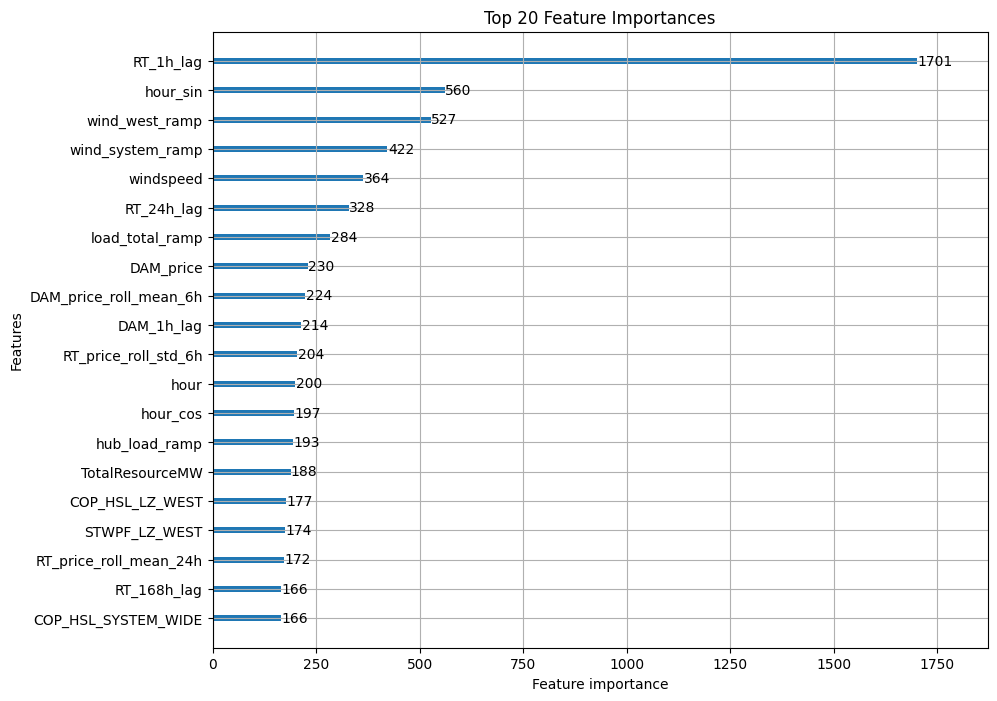

In [61]:
import matplotlib.pyplot as plt
# Feature importance
lgb.plot_importance(grid.best_estimator_, max_num_features=20, figsize=(10,8))
plt.title('Top 20 Feature Importances')

In [62]:
# Slower model to see if score improves

lgbm_slow = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=-1,
    num_leaves=63,
    class_weight='balanced',
    random_state=42,
    verbose=0
)
lgbm_slow.fit(X_train, y_train)
print(classification_report(y_test, lgbm_slow.predict(X_test)))

              precision    recall  f1-score   support

         Low       0.78      0.87      0.82       644
      Normal       0.97      0.96      0.96      7559
    Scarcity       0.36      0.24      0.29        50
       Tight       0.61      0.63      0.62       505

    accuracy                           0.93      8758
   macro avg       0.68      0.67      0.67      8758
weighted avg       0.93      0.93      0.93      8758



## 24 hour model

In [63]:
drop_24h = ['timestamp', 'RT_price', 'RT_DAM_spread', 'RT_price_ramp', 'regime',
    'RT_1h_lag', 'DAM_1h_lag',
    'RT_price_roll_mean_6h', 'RT_price_roll_std_6h',
    'DAM_price_roll_mean_6h', 'DAM_price_roll_std_6h',
    'hub_load_roll_mean_6h', 'hub_load_roll_std_6h',
    'load_total_roll_mean_6h', 'load_total_roll_std_6h',
    'WGRPP_LZ_WEST_roll_mean_6h', 'WGRPP_LZ_WEST_roll_std_6h',
    'load_total_ramp', 'hub_load_ramp',
    'wind_west_ramp', 'wind_system_ramp',
    'hub_load', 'load_total',
    'WGRPP_LZ_WEST', 'WGRPP_SYSTEM_WIDE',
    'PVGRPP_SYSTEM_WIDE',
    'net_load_system', 'net_load_west',
    'renewable_pct_system', 'renewable_pct_west'
]

X_train_24h = train.drop(columns=drop_24h)
y_train_24h = train['regime']
X_val_24h = val.drop(columns=drop_24h)
y_val_24h = val['regime']
X_test_24h = test.drop(columns=drop_24h)
y_test_24h = test['regime']

print('24h features:', X_train_24h.columns.tolist())
print('Feature count:', X_train_24h.shape[1])

24h features: ['DAM_price', 'temperature', 'humidity', 'windspeed', 'precipitation', 'TotalResourceMWZoneWest', 'TotalResourceMW', 'STPPF_SYSTEM_WIDE', 'COP_HSL_SYSTEM_WIDE', 'STWPF_LZ_WEST', 'COP_HSL_LZ_WEST', 'West', 'SystemTotal', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'RT_24h_lag', 'RT_168h_lag', 'DAM_24h_lag', 'DAM_168h_lag', 'hub_load_24h_lag', 'load_total_24h_lag', 'wind_24h_lag', 'wind_168h_lag', 'RT_price_roll_mean_24h', 'RT_price_roll_std_24h', 'DAM_price_roll_mean_24h', 'DAM_price_roll_std_24h', 'hub_load_roll_mean_24h', 'hub_load_roll_std_24h', 'load_total_roll_mean_24h', 'load_total_roll_std_24h', 'WGRPP_LZ_WEST_roll_mean_24h', 'WGRPP_LZ_WEST_roll_std_24h']
Feature count: 37


In [64]:
models_24h = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
}

for name, model in models_24h.items():
    model.fit(X_train_24h, y_train_24h)
    y_pred = model.predict(X_test_24h)
    print(f'\n----{name}----')
    print(classification_report(y_test_24h, y_pred))


----Logistic Regression----
              precision    recall  f1-score   support

         Low       0.55      0.74      0.63       644
      Normal       0.91      0.95      0.93      7559
    Scarcity       0.00      0.00      0.00        50
       Tight       0.33      0.01      0.01       505

    accuracy                           0.87      8758
   macro avg       0.45      0.42      0.39      8758
weighted avg       0.84      0.87      0.85      8758


----Random Forest----
              precision    recall  f1-score   support

         Low       0.59      0.65      0.62       644
      Normal       0.91      0.96      0.93      7559
    Scarcity       0.50      0.02      0.04        50
       Tight       0.62      0.07      0.13       505

    accuracy                           0.88      8758
   macro avg       0.65      0.42      0.43      8758
weighted avg       0.87      0.88      0.86      8758


----LightGBM----
              precision    recall  f1-score   support

     

In [65]:
param_grid_24h = {
    'n_estimators': [100, 300],
    'max_depth': [3, 5, -1],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 63]
}

lgbm_24h = lgb.LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1)
tscv = TimeSeriesSplit(n_splits=3)

grid_24h = GridSearchCV(
    lgbm_24h,
    param_grid_24h,
    cv=tscv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)

grid_24h.fit(X_train_24h, y_train_24h)
print('Best params:', grid_24h.best_params_)
print(classification_report(y_test_24h, grid_24h.best_estimator_.predict(X_test_24h)))

Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 63}
              precision    recall  f1-score   support

         Low       0.45      0.83      0.58       644
      Normal       0.96      0.83      0.89      7559
    Scarcity       0.16      0.24      0.19        50
       Tight       0.33      0.61      0.43       505

    accuracy                           0.82      8758
   macro avg       0.47      0.63      0.52      8758
weighted avg       0.88      0.82      0.84      8758



In [66]:
print('Best params:', grid_24h.best_params_)
print(classification_report(y_test_24h, grid_24h.best_estimator_.predict(X_test_24h)))

Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 63}
              precision    recall  f1-score   support

         Low       0.45      0.83      0.58       644
      Normal       0.96      0.83      0.89      7559
    Scarcity       0.16      0.24      0.19        50
       Tight       0.33      0.61      0.43       505

    accuracy                           0.82      8758
   macro avg       0.47      0.63      0.52      8758
weighted avg       0.88      0.82      0.84      8758



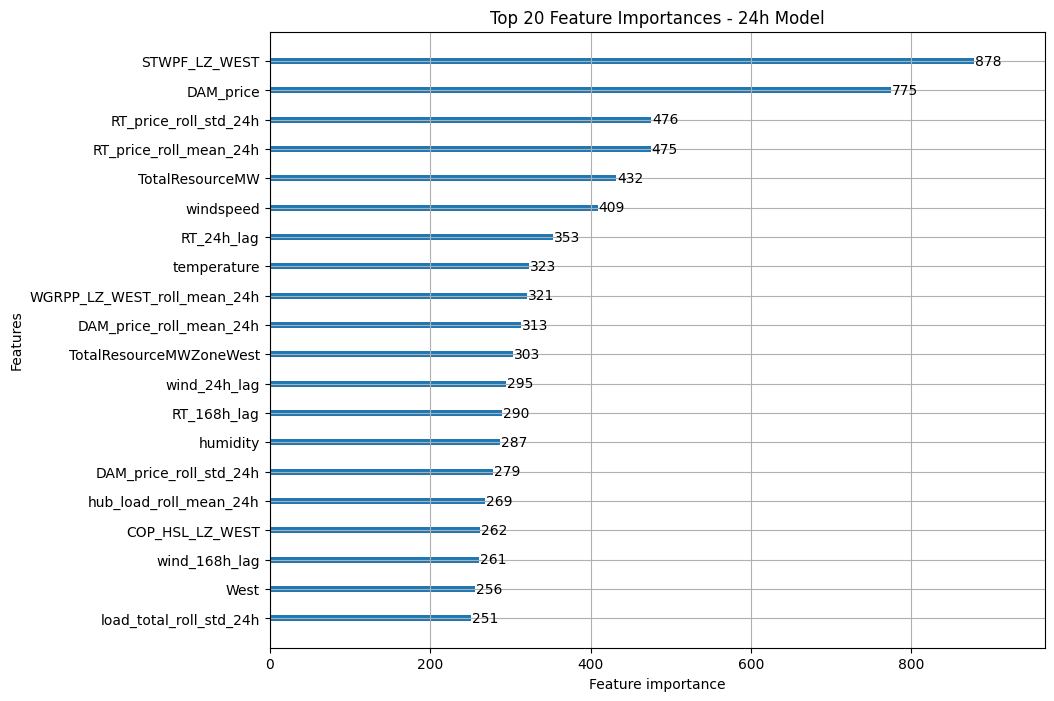

In [67]:
# Feature importance

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('white')
lgb.plot_importance(grid_24h.best_estimator_, max_num_features=20, ax=ax)
ax.set_title('Top 20 Feature Importances - 24h Model')
plt.savefig(PROJECT_PATH + 'images/feature_importance_24h.png', bbox_inches='tight', dpi=150, facecolor='white')

### Custom Weight experiment

Custom weights (Scarcity: 50x) boosted scarcity recall to 0.46 but crashed Tight recall to 0.41. Tradeoff not worth it.

In [68]:
lgbm_custom = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    class_weight={'Low': 1, 'Normal': 1, 'Tight': 5, 'Scarcity': 50},
    random_state=42,
    verbose=-1
)
tscv = TimeSeriesSplit(n_splits=3)

grid_24h_custom = GridSearchCV(
    lgbm_custom,
    param_grid_24h,
    cv=tscv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)

grid_24h_custom.fit(X_train_24h, y_train_24h)
print('Best params:', grid_24h_custom.best_params_)
print(classification_report(y_test_24h, grid_24h_custom.best_estimator_.predict(X_test_24h)))

Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 31}
              precision    recall  f1-score   support

         Low       0.58      0.65      0.61       644
      Normal       0.94      0.92      0.93      7559
    Scarcity       0.13      0.36      0.19        50
       Tight       0.38      0.38      0.38       505

    accuracy                           0.86      8758
   macro avg       0.51      0.58      0.53      8758
weighted avg       0.87      0.86      0.87      8758



In [69]:
print('Best params:', grid_24h_custom.best_params_)
print(classification_report(y_test_24h, grid_24h_custom.best_estimator_.predict(X_test_24h)))

Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 31}
              precision    recall  f1-score   support

         Low       0.58      0.65      0.61       644
      Normal       0.94      0.92      0.93      7559
    Scarcity       0.13      0.36      0.19        50
       Tight       0.38      0.38      0.38       505

    accuracy                           0.86      8758
   macro avg       0.51      0.58      0.53      8758
weighted avg       0.87      0.86      0.87      8758



## Test without Uri

In [70]:
train_no_uri = train[~((train['timestamp'].dt.year == 2021) & (train['timestamp'].dt.month == 2))]

X_train_no_uri = train_no_uri.drop(columns=drop_cols)
y_train_no_uri = train_no_uri['regime']

lgbm_no_uri = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)
lgbm_no_uri.fit(X_train_no_uri, y_train_no_uri)
print(classification_report(y_test, lgbm_no_uri.predict(X_test)))

              precision    recall  f1-score   support

         Low       0.71      0.86      0.78       644
      Normal       0.97      0.93      0.95      7559
    Scarcity       0.29      0.32      0.30        50
       Tight       0.52      0.75      0.62       505

    accuracy                           0.91      8758
   macro avg       0.62      0.71      0.66      8758
weighted avg       0.92      0.91      0.91      8758



In [71]:
print(classification_report(y_test, lgbm_no_uri.predict(X_test)))

              precision    recall  f1-score   support

         Low       0.71      0.86      0.78       644
      Normal       0.97      0.93      0.95      7559
    Scarcity       0.29      0.32      0.30        50
       Tight       0.52      0.75      0.62       505

    accuracy                           0.91      8758
   macro avg       0.62      0.71      0.66      8758
weighted avg       0.92      0.91      0.91      8758



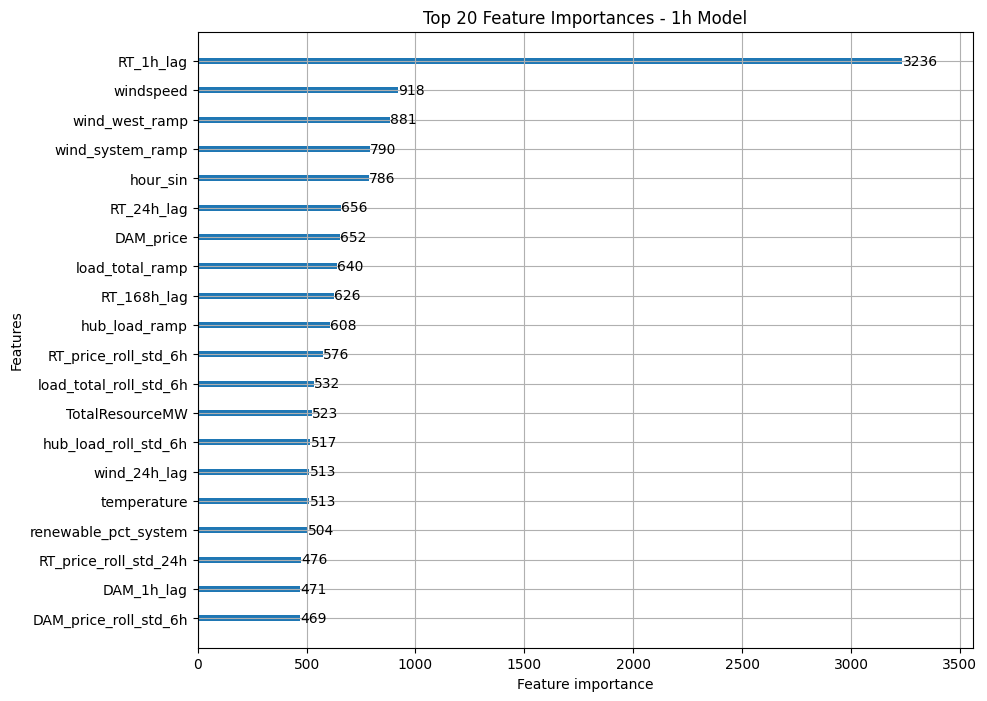

In [72]:
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('white')
lgb.plot_importance(lgbm_no_uri, max_num_features=20, ax=ax)
ax.set_title('Top 20 Feature Importances - 1h Model')
plt.savefig(PROJECT_PATH + 'images/feature_importance_1h.png', bbox_inches='tight', dpi=150, facecolor='white')

In [73]:
train_no_uri_24h = train[~((train['timestamp'].dt.year == 2021) & (train['timestamp'].dt.month == 2))]
X_train_no_uri_24h = train_no_uri_24h.drop(columns=drop_24h)
y_train_no_uri_24h = train_no_uri_24h['regime']

lgbm_no_uri_24h = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=63,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)
lgbm_no_uri_24h.fit(X_train_no_uri_24h, y_train_no_uri_24h)
print(classification_report(y_test_24h, lgbm_no_uri_24h.predict(X_test_24h)))

              precision    recall  f1-score   support

         Low       0.49      0.80      0.61       644
      Normal       0.96      0.86      0.91      7559
    Scarcity       0.19      0.20      0.19        50
       Tight       0.36      0.61      0.45       505

    accuracy                           0.84      8758
   macro avg       0.50      0.62      0.54      8758
weighted avg       0.88      0.84      0.85      8758



In [74]:
print(classification_report(y_test_24h, lgbm_no_uri_24h.predict(X_test_24h)))

              precision    recall  f1-score   support

         Low       0.49      0.80      0.61       644
      Normal       0.96      0.86      0.91      7559
    Scarcity       0.19      0.20      0.19        50
       Tight       0.36      0.61      0.45       505

    accuracy                           0.84      8758
   macro avg       0.50      0.62      0.54      8758
weighted avg       0.88      0.84      0.85      8758



## Check for Overfitting

F1 scores are very close in the 1 hour model and 24 hour model. Slight overfitting but acceptable.

In [75]:
# 1 hour model
from sklearn.metrics import f1_score
print('Train F1:', f1_score(y_train_no_uri, lgbm_no_uri.predict(X_train_no_uri), average='weighted'))
print('Test F1:', f1_score(y_test, lgbm_no_uri.predict(X_test), average='weighted'))

Train F1: 0.9423833189306993
Test F1: 0.913940478334812


In [76]:
# 24 hour model
print('Train F1:', f1_score(y_train_24h, grid_24h.best_estimator_.predict(X_train_24h), average='weighted'))
print('Test F1:', f1_score(y_test_24h, grid_24h.best_estimator_.predict(X_test_24h), average='weighted'))

Train F1: 0.8849191729313141
Test F1: 0.837805355482599


## Winning Models

1. **1h model (excl. Uri)** — F1: 0.91. Excluding Uri improved scarcity recall because the model stopped overfitting to extreme cold/outage patterns and learned more typical scarcity signals instead.

2. **24h model (incl. Uri)** — F1: 0.86. Top features shift from price momentum to fundamentals: wind forecast, DAM price, rolling stats, outages. Shift from technical to fundamental analysis at longer horizons.

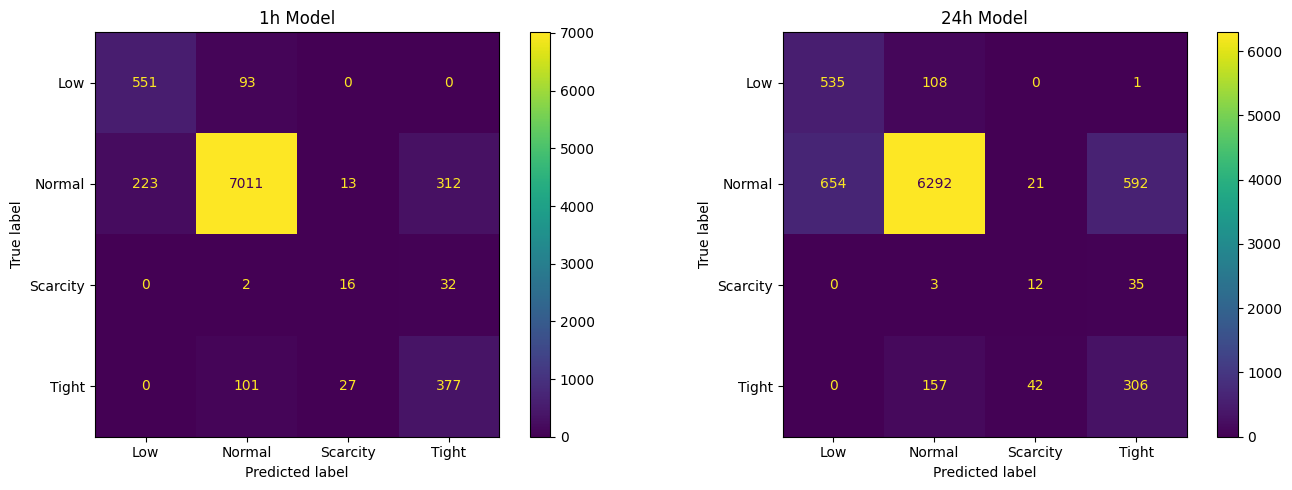

In [77]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

ConfusionMatrixDisplay.from_estimator(lgbm_no_uri, X_test, y_test, ax=axes[0])
axes[0].set_title('1h Model')

ConfusionMatrixDisplay.from_estimator(grid_24h.best_estimator_, X_test_24h, y_test_24h, ax=axes[1])
axes[1].set_title('24h Model')

plt.tight_layout()
plt.savefig(PROJECT_PATH + 'images/confusion_matrices.png', bbox_inches='tight', dpi=150, facecolor='white')

In [78]:
# Save winning models

import joblib
os.makedirs(PROJECT_PATH + 'models/', exist_ok=True)

joblib.dump(lgbm_no_uri, PROJECT_PATH + "models/lgbm_1h_regime.pkl")
joblib.dump(grid_24h.best_estimator_, PROJECT_PATH + "models/lgbm_24h_regime.pkl")

['/Users/kamilmadey/Desktop/ercot_forecasting_project/models/lgbm_24h_regime.pkl']

## Probability Evaluation

In [79]:
import sys
sys.path.append(PROJECT_PATH + 'src/models/')
from decision_layer import mining_backtest, datacenter_backtest, optimize_thresholds

In [80]:
# Validating probabilities for 1h and 24h models

val_proba_1h = lgbm_no_uri.predict_proba(X_val)
val_preds_1h = pd.DataFrame({'prob_Scarcity': val_proba_1h[:,list(lgbm_no_uri.classes_).index('Scarcity')],'prob_Tight': val_proba_1h[:,list(lgbm_no_uri.classes_).index('Tight')]})

val_proba_24h = grid_24h.best_estimator_.predict_proba(X_val_24h)
val_preds_24h = pd.DataFrame({'prob_Scarcity': val_proba_24h[:,list(grid_24h.best_estimator_.classes_).index('Scarcity')], 'prob_Tight': val_proba_24h[:,list(grid_24h.best_estimator_.classes_).index('Tight')]})

# Test probabilities for 1h and 24h models

test_proba_1h = lgbm_no_uri.predict_proba(X_test)
test_preds_1h = pd.DataFrame({'prob_Scarcity': test_proba_1h[:,list(lgbm_no_uri.classes_).index('Scarcity')],'prob_Tight': test_proba_1h[:,list(lgbm_no_uri.classes_).index('Tight')]})

test_proba_24h = grid_24h.best_estimator_.predict_proba(X_test_24h)
test_preds_24h = pd.DataFrame({'prob_Scarcity': test_proba_24h[:,list(grid_24h.best_estimator_.classes_).index('Scarcity')],'prob_Tight': test_proba_24h[:,list(grid_24h.best_estimator_.classes_).index('Tight')]})

In [81]:
# Find optimal thresholds for scarcity and tight classes

best_params_1h_mining,_ = optimize_thresholds(val, val_preds_1h, mining_backtest)
best_params_24h_mining,_ = optimize_thresholds(val, val_preds_24h, mining_backtest)

best_params_1h_dc,_ = optimize_thresholds(val, val_preds_1h, datacenter_backtest)
best_params_24h_dc,_ = optimize_thresholds(val, val_preds_24h, datacenter_backtest)

In [82]:
print(f"1h Mining: {best_params_1h_mining}")
print(f"24h Mining: {best_params_24h_mining}")
print(f"1h Datacenter: {best_params_1h_dc}")
print(f"24h Datacenter: {best_params_24h_dc}")

1h Mining: {'scarcity': np.float64(0.1), 'tight': np.float64(0.15000000000000002)}
24h Mining: {'scarcity': np.float64(0.1), 'tight': np.float64(0.30000000000000004)}
1h Datacenter: {'scarcity': np.float64(0.05), 'tight': np.float64(0.35000000000000003)}
24h Datacenter: {'scarcity': np.float64(0.05), 'tight': np.float64(0.5)}


## Backtest on Test DF

In [83]:
mining_1h = mining_backtest(test, test_preds_1h, scarcity_threshold=best_params_1h_mining['scarcity'], tight_threshold=best_params_1h_mining['tight'])
mining_24h = mining_backtest(test, test_preds_24h, scarcity_threshold=best_params_24h_mining['scarcity'], tight_threshold=best_params_24h_mining['tight'])

dc_1h = datacenter_backtest(test, test_preds_1h, scarcity_threshold=best_params_1h_dc['scarcity'], tight_threshold=best_params_1h_dc['tight'])
dc_24h = datacenter_backtest(test, test_preds_24h, scarcity_threshold=best_params_24h_dc['scarcity'], tight_threshold=best_params_24h_dc['tight'])

Always-on cost: $-12,376,252
Model-guided cost: $-24,177,981
Savings: $11,801,729
Hours curtailed: 1483 / 8758
Always-on cost: $-12,376,252
Model-guided cost: $-23,051,604
Savings: $10,675,351
Hours curtailed: 1890 / 8758
Always-on cost: $57,687,748
Model-guided cost: $55,211,379
Savings: $2,476,368
Hours at reduced load: 1022 / 8758
Always-on cost: $57,687,748
Model-guided cost: $55,577,497
Savings: $2,110,251
Hours at reduced load: 1559 / 8758


In [84]:
# Attach predictions to test for analysis
test_analysis = test.copy()
test_analysis['prob_Scarcity'] = test_preds_1h['prob_Scarcity'].values
test_analysis['true_regime'] = y_test.values

# False negatives — actual scarcity, model didn't flag it
missed_scarcity = test_analysis[
    (test_analysis['true_regime'] == 'Scarcity') & 
    (test_analysis['prob_Scarcity'] <= best_params_1h_mining['scarcity'])
]

# True positives — actual scarcity, model caught it
caught_scarcity = test_analysis[
    (test_analysis['true_regime'] == 'Scarcity') & 
    (test_analysis['prob_Scarcity'] > best_params_1h_mining['scarcity'])
]

print(f"Caught: {len(caught_scarcity)}, Missed: {len(missed_scarcity)}")
print(f"Missed scarcity prob distribution:\n{missed_scarcity['prob_Scarcity'].describe()}")

Caught: 31, Missed: 19
Missed scarcity prob distribution:
count    19.000000
mean      0.037960
std       0.027956
min       0.009409
25%       0.015135
50%       0.021850
75%       0.065895
max       0.084786
Name: prob_Scarcity, dtype: float64


In [85]:
print(f"Total scarcity hours in test: {(test_analysis['true_regime'] == 'Scarcity').sum()}")
print(f"Caught (true positives): {len(caught_scarcity)}")
print(f"Missed (false negatives): {len(missed_scarcity)}")

# Also check false positives — model flagged scarcity but it wasn't
false_alarms = test_analysis[
    (test_analysis['true_regime'] != 'Scarcity') & 
    (test_analysis['prob_Scarcity'] > best_params_1h_mining['scarcity'])
]
print(f"False alarms: {len(false_alarms)}")
print(f"What were they actually? \n{false_alarms['true_regime'].value_counts()}")

Total scarcity hours in test: 50
Caught (true positives): 31
Missed (false negatives): 19
False alarms: 239
What were they actually? 
true_regime
Tight     160
Normal     79
Name: count, dtype: int64


In [ ]:
# Probability Calculation

In [ ]:
## Threshold Sensitivity


## Observations

### Model Selection
- LightGBM outperformed Logistic Regression and Random Forest across both models
- class_weight='balanced' significantly improved Tight and Scarcity recall by penalizing minority class misses
- Removing Winter Storm Uri from 1h training improved scarcity recall — extreme tail events added noise for typical scarcity patterns
- 1h model relies on price momentum (RT_1h_lag), 24h model shifts to fundamentals (wind forecast, DAM price)

### Probability-Based Dispatch
- Probability thresholds outperform hard label classification for economic dispatch decisions
- Optimal thresholds vary by use case: mining (scarcity=0.10, tight=0.15) vs datacenter (scarcity=0.05, tight=0.35) — reflects different cost asymmetries
- 1h model consistently outperforms 24h for dispatch — precision matters more than lead time
- Mining backtest: $11.8M savings (1h) with 1,483 hours curtailed out of 8,758
- Datacenter backtest: $2.5M savings (1h) at $50/MWh curtailment penalty

### Error Analysis
- 62% scarcity recall at optimized threshold — 31 of 50 scarcity hours caught
- 19 missed scarcity hours had mean probability of 0.038 — genuine model blind spots, not near-misses
- 239 false alarms, but 67% were actually Tight hours — model fails gracefully
- Cost asymmetry justifies low thresholds: missing a $5,000/MWh spike far exceeds cost of unnecessary curtailments

### Next Steps
- Add ORDC price adder data as scarcity signal feature to address model blind spots
- Implement probability calibration (isotonic regression) to improve reliability of predicted probabilities
- Build battery storage backtest with charge/discharge decision layer